In [1358]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1359]:
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
from networkx.algorithms import smallworld
import random
from collections import Counter
from scipy.spatial import cKDTree

from tqdm import tqdm

In [1360]:
from src.neuron_population import NeuronPopulation
from src.connectome import Connectome
from src.overhead import Simulation
from src.neuron_templates import neuron_type_IZ
from src.network_grower import *
from src.network_generators import *
from src.neuron_type_distributor import *
from src.network_weight_distributor import *
from src.external_inputs import *

In [1361]:
delay_mean_E = 10.0
delay_std_E = delay_mean_E * 0.3
delay_mean_I = 1.5
delay_std_I = delay_mean_I * 0.3
v_ext = 50.0

excitatory_type = "ss4"
inhibitory_type = "b"

In [1362]:
seed = 1234

## Generate network

In [1363]:
n_neurons = int(1000 * 1.0)

I_percent = 0.2

n_excitatory = int(n_neurons * (1 - I_percent))

In [ ]:
type_fractions = {
    "ss4": 0.8,
    "b": 0.2,
}

inhibitory_types = ("b")

p0_by_pair = {"EE": 0.5, "EI": 0.5, "IE": 0.5, "II": 0.5}

lambda_by_preclass = {"E": 0.2, "I": 0.2} # Distance factor

weight_dist_by_ntype = {"ss4": "lognormal", "b": "normal"}

outdegree_config_by_type = {
        # lognormal: params = (mu, sigma), then k = floor(exp(N(mu,sigma)))
        "ss4": {"dist": "lognormal", "params": (2.65, 0.8)},  # higher mean out-degree
        "b":   {"dist": "neg-bin", "params": (50, 40)},  # lower mean out-degree
        # "b":   {"dist": "lognormal", "params": (2.65, 0.8)},  # lower mean out-degree
    }

normalize_mode = "in"

# For fixed
# normalize_target_in_E = {"ss4": 50.0, "b": 20.0}
# normalize_target_in_I = {"ss4": 250.0, "b": 25.0}


# For spatial
normalize_target_in_E = {"ss4": 50.0, "b": 10.0}
normalize_target_in_I = {"ss4": 500.0, "b": 50.0}

G = generate_spatial_ei_network(n_neurons=n_neurons, type_fractions=type_fractions,
                                inhibitory_types=inhibitory_types,
                                mu_E=0.0, sigma_E=1.6, mu_I=30.0, sigma_I=6.0,
                                p0_by_pair=p0_by_pair,
                                lambda_by_preclass=lambda_by_preclass,
                                distance_scale=20.0,
                                weight_dist_by_ntype=weight_dist_by_ntype,
                                outdegree_config_by_type=outdegree_config_by_type,
                                normalize_mode=normalize_mode,
                                normalize_target_in_E=normalize_target_in_E,
                                normalize_target_in_I=normalize_target_in_I,)

# G = generate_random_fixed_indegree_ei_network(
#         n_neurons=n_neurons,
#         indegree=100,
#         type_fractions=type_fractions,
#         inhibitory_types=inhibitory_types,
#         delay_mean_E=10.0,
#         delay_std_E=3.0,
#         delay_mean_I=1.5,
#         delay_std_I=0.45,
#         mu_E=0.0,
#         sigma_E=1.6,
#         mu_I=30.0,
#         sigma_I=6.0,
#         weight_dist_by_ntype=weight_dist_by_ntype,
#         normalize_mode="in",
#         normalize_target_in_E=normalize_target_in_E,
#         normalize_target_in_I=normalize_target_in_I,
#         seed=seed,
#     )

In [1365]:
all_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(all_weights)

ss4_weights = [G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['ntype'] == "ss4"]
max_ss4_weight = max(ss4_weights)
b_weights = [G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['ntype'] == "b"]
max_b_weight = max(b_weights)

Text(0.5, 1.0, 'b Weight Distribution after Lognormal Redistribution')

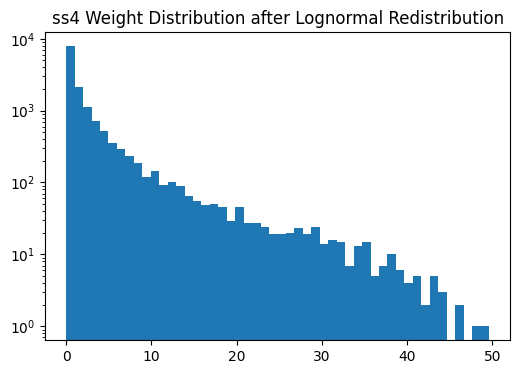

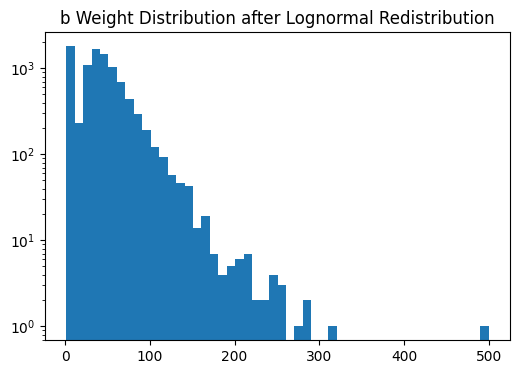

In [1366]:
# Plot ss4 weight distribution
plt.figure(figsize=(6,4))
plt.hist(ss4_weights, bins=50, log=True)
plt.title(f"ss4 Weight Distribution after Lognormal Redistribution")

# Plot b weight distribution
plt.figure(figsize=(6,4))
plt.hist(b_weights, bins=50, log=True)
plt.title(f"b Weight Distribution after Lognormal Redistribution")

In [1367]:
# How many percentage of edges with weight less than 1.0?
threshold = 100.0
percent_less_than_1 = sum(w < threshold for w in weights) / len(weights) * 100
print(f"Percentage of edges with weight less than {threshold}: {percent_less_than_1:.2f}%")

Percentage of edges with weight less than 100.0: 100.00%


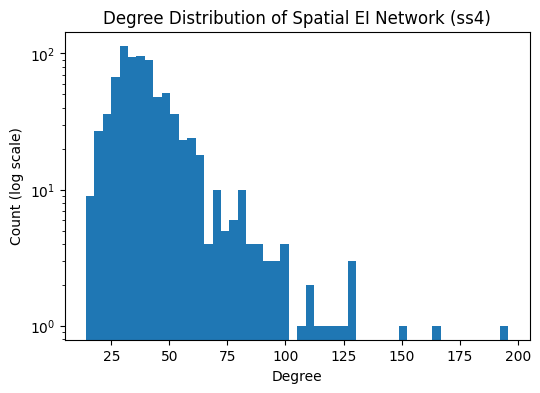

In [1368]:
# Plot degree distribution
n_type_show = "ss4"
degrees = [G.degree(n) for n in G.nodes() if G.nodes[n]['ntype'] == n_type_show]
plt.figure(figsize=(6,4))
plt.hist(degrees, bins=50, log=True)
plt.title(f"Degree Distribution of Spatial EI Network ({n_type_show})")
plt.xlabel("Degree")
plt.ylabel("Count (log scale)")
plt.show()

In [1369]:
enable_plot = False

if enable_plot:
    # Plot graph G using "pos" attribute for node positions
    pos = nx.get_node_attributes(G, 'pos')
    # Edge thinckness proportional to weight
    edges = G.edges()
    weights = [G[u][v]['weight'] / 100.0 for u, v in edges]
    # Node size proportional to degree
    degrees = [G.degree(n) for n in G.nodes()]
    # Node color by neuron type
    ntypes = nx.get_node_attributes(G, 'ntype')
    # Map neuron types to colors
    color_map = {'ss4': 'blue', 'b': 'red'}
    node_colors = [color_map.get(ntypes[n], 'gray') for n in G.nodes()]
    # Edge alpha
    alphas = [0.2 + 0.8 * G[u][v]['weight'] / 10.0 for u, v in edges]
    plt.figure(figsize=(8,8))
    nx.draw(G, pos, node_size=degrees, width=weights, edge_cmap=plt.cm.viridis, node_color=node_colors, alpha=0.65, with_labels=False)
    plt.title("Spatial EI Network Visualization")
    plt.show()

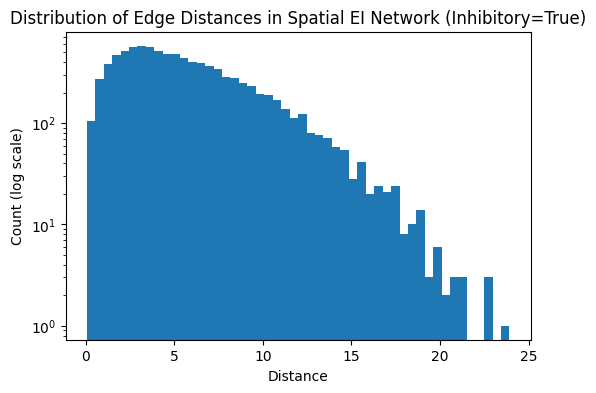

In [1370]:
# Print distribution of "distance" attribute for edges
if_inhibitory = True
distances = [G[u][v]['distance'] for u, v in G.edges() if G.nodes[u]['inhibitory'] == if_inhibitory]
plt.figure(figsize=(6,4))
plt.hist(distances, bins=50, log=True)
plt.title(f"Distribution of Edge Distances in Spatial EI Network (Inhibitory={if_inhibitory})")
plt.xlabel("Distance")
plt.ylabel("Count (log scale)")
plt.show()

In [1371]:
# Excitatory out-weight sum
out_weight_sums = []
for n in G.nodes():
    if G.nodes[n]['ntype'] == 'ss4':  # Excitatory
        out_weight_sum = sum(G[n][nbr]['weight'] for nbr in G.neighbors(n))
        # Divide by out-degree to get average weight per outgoing edge
        out_degree = G.degree(n)
        if out_degree > 0:
            out_weight_sum /= out_degree
        out_weight_sums.append(out_weight_sum)

# Inhibitory out-weight sum
out_weight_sums_inh = []
for n in G.nodes():
    if G.nodes[n]['ntype'] == 'b':  # Inhibitory
        out_weight_sum = sum(G[n][nbr]['weight'] for nbr in G.neighbors(n))
        # Divide by out-degree to get average weight per outgoing edge
        out_degree = G.degree(n)
        if out_degree > 0:
            out_weight_sum /= out_degree
        out_weight_sums_inh.append(out_weight_sum)

np.array(out_weight_sums).mean(), np.array(out_weight_sums_inh).mean()

(np.float64(1.0656613907516128), np.float64(28.83389006635436))

In [1372]:
# Average excitatory out weight
out_weights_E = []
out_weights_I = []    

for n in G.nodes():
    if G.nodes[n]['ntype'] == 'b':
        out_weights_I.extend([G[n][nbr]['weight'] for nbr in G.successors(n)])
    else:
        out_weights_E.extend([G[n][nbr]['weight'] for nbr in G.successors(n)])

print(f"Average excitatory out weight: {np.mean(out_weights_E):.3f}")
print(f"Average inhibitory out weight: {np.mean(out_weights_I):.3f}")

Average excitatory out weight: 2.873
Average inhibitory out weight: 43.794


## Simulation setup

In [1373]:
dt = 0.1

In [1374]:
# Neuron population parameters
n_neurons = G.number_of_nodes()
neuron_types = [excitatory_type, inhibitory_type]
n_neuron_types = len(neuron_types)
inhibitory = [False, True]
threshold_decay = np.exp(-dt / 5)

pop = NeuronPopulation(n_neurons, neuron_types, inhibitory, threshold_decay)

In [1375]:
# Connectome
# Max number of outgoing synapses per neuron
max_synapses = max(dict(G.out_degree()).values())

connectome = Connectome(max_synapses, pop)

connectome.nx_to_connectome(G)

In [1376]:
# Keep old weights
W_old = connectome.W.copy()

In [1377]:
nmda_weight = np.ones(connectome.neuron_population.n_neurons, dtype=float)
nmda_weight[pop.inhibitory_mask.astype(bool)] = 0.959685703507305 * 0.5
# Invert to make excitatory neurons have NMDA weight 1, inhibitory 0
# nmda_weight

In [1378]:
# connectome.compute_metrics(small_world=False)

## Find output neurons

In [1379]:
# Choose top 5 % of neurons by out-degree
out_degrees = dict(G.out_degree())
top_neurons = sorted(out_degrees, key=out_degrees.get, reverse=True)[:int(0.05 * len(out_degrees))]
# Shuffle top neurons to avoid any ordering effects
random.shuffle(top_neurons)

## Input masks

In [1380]:
inhib_mask = pop.inhibitory_mask.astype(bool)
excit_mask = ~inhib_mask
input_mask = excit_mask.copy()
input_mask[:500] = False

## Plastic mask

In [1381]:
plastic_mask = excit_mask.copy()

## Potentials for Clopath

In [1382]:
resting_potentials = np.zeros(n_neurons)

for i in range(n_neurons):
    resting_potentials[i] = neuron_type_IZ[G.nodes[i]["ntype"]][5]

threshold_potentials = np.zeros(n_neurons)

for i in range(n_neurons):
    threshold_potentials[i] = neuron_type_IZ[G.nodes[i]["ntype"]][6]

## Simulation

In [1383]:
def sim_w_input(sim, sim_len_ms, input_mask, input_rate, input_amp):
    poisson = PoissonInput(n_neurons, rate=input_rate * input_mask, amplitude=input_amp)
    steps = int(sim_len_ms / dt)
    for _ in tqdm(range(steps)):
        sim.step(spike_ext=poisson(dt), reward=1.0)

100%|██████████| 20000/20000 [00:04<00:00, 4925.82it/s]


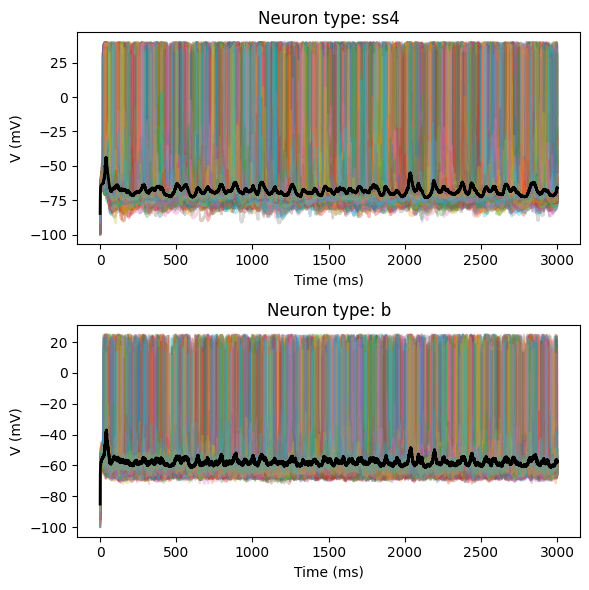

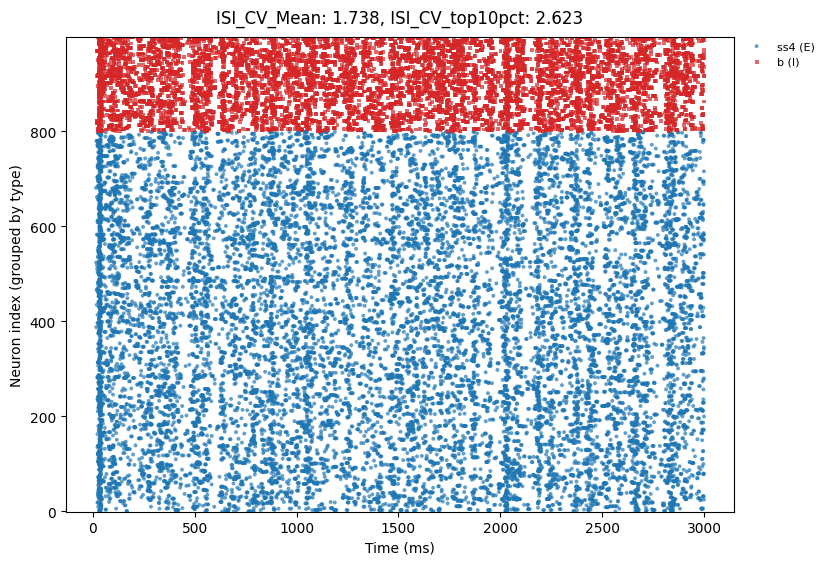

In [ ]:

# Randomize initial voltages
Vs = rng.uniform(-100, -70, size=n_neurons)
us = rng.uniform(0, 400, size=n_neurons)
spikes = np.zeros(n_neurons, dtype=bool)
Ts = np.zeros_like(spikes)

state0 = (Vs,
          us,
          spikes.copy(),
          Ts.copy())

# sim = Simulation(connectome, dt, stepper_type="simple", state0=state0,
#                  enable_plasticity=False)
sim = Simulation(connectome, dt, stepper_type="euler_det", state0=state0,
                 synapse_kwargs={"LT_scale": 1.0, "NMDA_weight": nmda_weight}, synapse_type="standard",
                 enable_debug_logger=True,
                 rate_normalization=#None,
                 {
                        "target_rate_hz": {"ss4": 3.5, "b": 19.0},
                        "eta_E": 0.001,
                        "eta_I": 0.001,
                        "rate_method": "window",   # or "ema"
                        "rate_window_ms": 200.0,   # for window mode
                        "rate_tau_ms": 200.0,      # for ema mode
                        "apply_every_ms": 200.0,    # None means every step
                        "min_weight": 0.0,
                        "max_weight": max_weight,
                    },
                    enable_plasticity=False, plasticity="clopath", plasticity_reward_type="online",
                 plasticity_kwargs={"plastic_source_mask": plastic_mask, "weight_multiplicity": None, 
                                    "max_weight": max_ss4_weight, "weight_update_scale": 1.0,
                                    # "enable_debug_logger": False, 
                                    "theta_minus": resting_potentials,
                                    "theta_plus": threshold_potentials
                                    }
                    ) 

sim.configure_output_readout(output_neuron_indices=top_neurons, output_dim=2, rate_window_ms=200.0)


sim_w_input(sim, sim_len_ms=1000.0, input_mask=input_mask, input_rate=v_ext, input_amp=0.5)

sim_w_input(sim, sim_len_ms=4000.0, input_mask=input_mask, input_rate=v_ext, input_amp=0.5)

sim.plot_voltage_per_type(figsize=(6, 6))

stats = sim.stats.compute_metrics(dt, bin_ms_participation=300)

isi_mean = stats['ISI_CV_mean']
isi_top = stats["ISI_CV_mean_top10pct"]

sim.plot_spike_raster(figsize=(10, 6), title=f"ISI_CV_Mean: {isi_mean:.3f}, ISI_CV_top10pct: {isi_top:.3f}", t_start_ms=0.0, t_stop_ms=15000.0)

In [1385]:
connectome.W.max()

np.float64(500.0)

In [1386]:
dW = connectome.W - W_old
dW.max()
dW.min()

np.float64(0.0)

In [1387]:
sim.stats.compute_metrics(dt, bin_ms_participation=300, t_start_ms=0000.0, t_stop_ms=3000.0)

{'mean_voltage_mV': -65.67914094631536,
 'min_voltage_mV': -90.3876663840638,
 'mean_voltage_mV_E': -67.70280032536589,
 'mean_voltage_mV_I': -57.58450343011237,
 'min_voltage_mV_E': -90.3876663840638,
 'min_voltage_mV_I': -72.05292292902323,
 'rate_mean_Hz': 10.226325789140361,
 'rate_median_Hz': 8.666377787407086,
 'rate_p95_Hz': 22.999233358888034,
 'rate_mean_Hz_E': 8.262224592513583,
 'rate_mean_Hz_I': 18.082730575647478,
 'rate_mean_Hz_E_active2spk': 8.292069896289949,
 'rate_mean_Hz_I_active2spk': 18.082730575647478,
 'ISI_CV_median': 1.6733269336137502,
 'ISI_CV_mean': 1.7071146010594815,
 'ISI_CV_mean_E': 1.671714515024584,
 'ISI_CV_mean_I': 1.8474759421878508,
 'ISI_CV_mean_top10pct': 2.591081322559039,
 'refractory_violations_per_neuron': 0.0,
 'Fano_median_2ms': 0.99266177451635,
 'Fano_median_10ms': 1.886636774596644,
 'Fano_median_50ms': 2.406779661016949,
 'Fano_median_100ms': 2.4482758620689626,
 'Fano_median_300ms': 2.4831649831649836,
 'Fano_median_500ms': 2.569473684

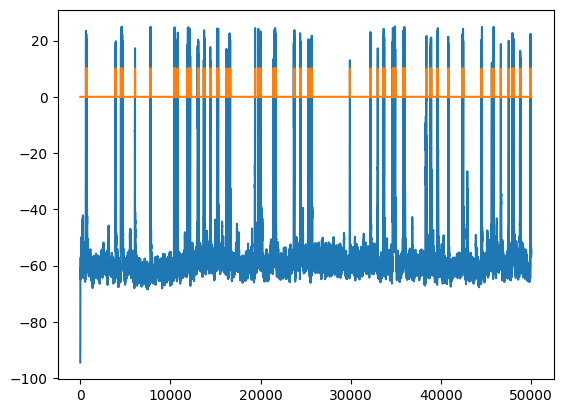

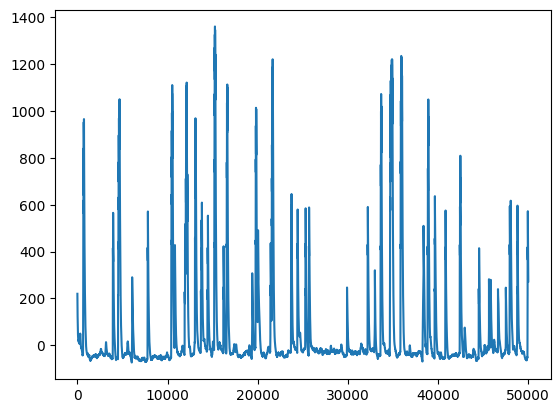

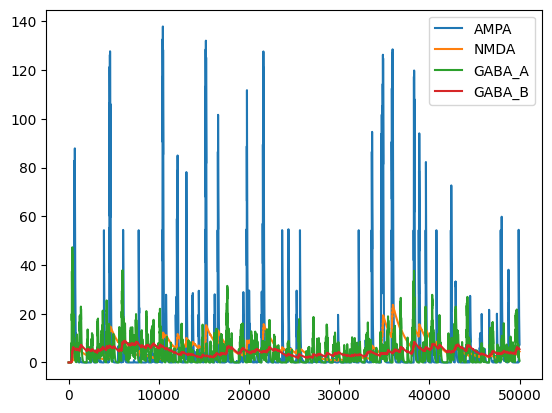

In [1388]:
# Plot spikes for one neuron
n_idx = 16
t_first = 0
t_last = -1
plt.plot(np.array(sim.stats.Vs)[t_first:t_last,n_idx])
plt.plot(np.array(sim.stats.spikes)[t_first:t_last,n_idx] * 10)
plt.show()
plt.plot(np.array(sim.stats.us)[t_first:t_last,n_idx])
plt.show()
plt.plot(np.array(sim.debug_logger.s_ampa)[t_first:t_last,n_idx], label="AMPA")
plt.plot(np.array(sim.debug_logger.s_nmda)[t_first:t_last,n_idx], label="NMDA")
plt.plot(np.array(sim.debug_logger.s_gaba_a)[t_first:t_last,n_idx], label="GABA_A")
plt.plot(np.array(sim.debug_logger.s_gaba_b)[t_first:t_last,n_idx], label="GABA_B")
plt.legend()
plt.show()

In [1389]:
# plt.plot(np.array(sim.debug_logger.s_ampa)[t_first:t_last,n_idx], label="AMPA")
# plt.plot(np.array(sim.debug_logger.s_nmda)[t_first:t_last,n_idx], label="NMDA")
# plt.plot(np.array(sim.debug_logger.s_gaba_a)[t_first:t_last,n_idx], label="GABA_A")
# plt.plot(np.array(sim.debug_logger.s_gaba_b)[t_first:t_last,n_idx], label="GABA_B")
# plt.legend()
# plt.show()

In [1390]:
# connectome.compute_metrics(small_world=False)